In [1]:
import scipy.io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline

from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

sns.set_theme(style="whitegrid")
import warnings
warnings.filterwarnings('ignore')

In [2]:
print("--- Phase 1: Data Preprocessing ---")

mat_data = scipy.io.loadmat('mnist-original.mat')

X = mat_data['data'].T 
y = mat_data['label'].flatten()

missing_values = np.isnan(X).sum()
print(f"Total missing values in dataset: {missing_values}")

if missing_values > 0:
    X = np.nan_to_num(X)

X = X.astype(np.float32)
y = y.astype(int)

print(f"Data shape: {X.shape}, Data type: {X.dtype}")
print(f"Labels shape: {y.shape}, Labels type: {y.dtype}")

--- Phase 1: Data Preprocessing ---
Total missing values in dataset: 0
Data shape: (70000, 784), Data type: float32
Labels shape: (70000,), Labels type: int64


In [3]:
print("\n--- Phase 2: Feature Engineering ---")




X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

pca = PCA(n_components=0.90, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print(f"Original feature count: {X_train_scaled.shape[1]}")
print(f"Feature count after PCA: {X_train_pca.shape[1]} (Retaining 90% variance)")


--- Phase 2: Feature Engineering ---
Original feature count: 784
Feature count after PCA: 234 (Retaining 90% variance)



--- Phase 3: Descriptive Analysis ---
Mean Pixel Intensity: 33.39
Standard Deviation: 78.65
Variance: 6186.51
Most Frequent Digit (Mode): 1


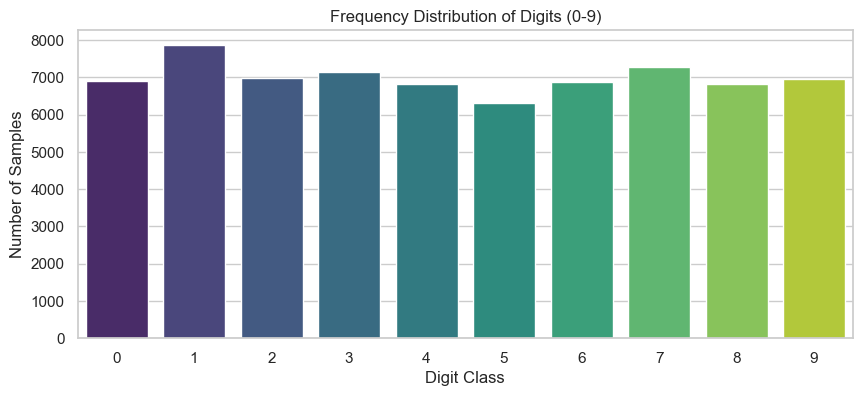

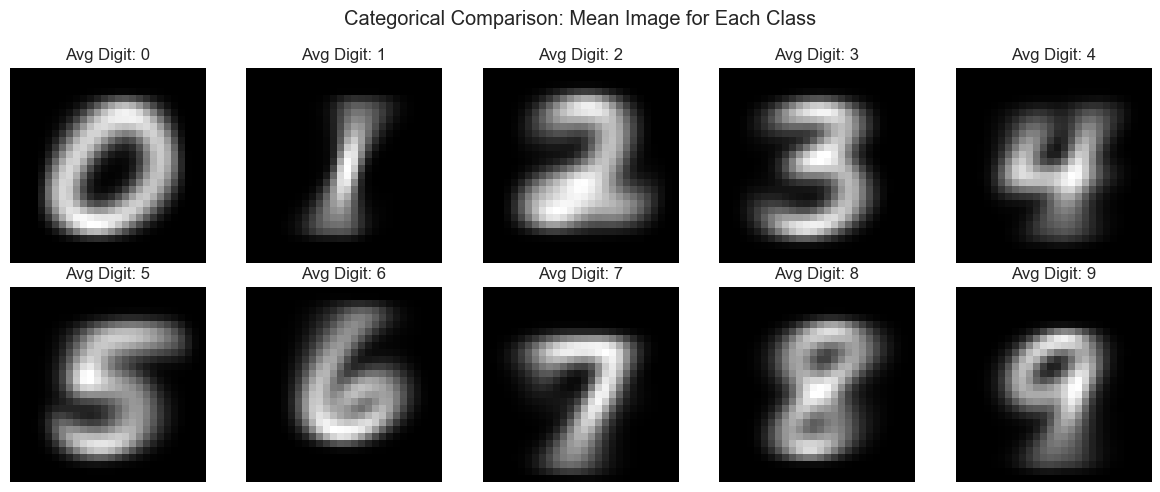

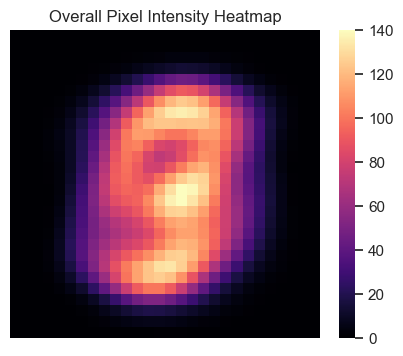

In [4]:
print("\n--- Phase 3: Descriptive Analysis ---")

pixel_mean = np.mean(X)
pixel_std = np.std(X)
pixel_var = np.var(X)
label_mode = stats.mode(y, keepdims=True).mode[0]

print(f"Mean Pixel Intensity: {pixel_mean:.2f}")
print(f"Standard Deviation: {pixel_std:.2f}")
print(f"Variance: {pixel_var:.2f}")
print(f"Most Frequent Digit (Mode): {label_mode}")

plt.figure(figsize=(10, 4))
sns.countplot(x=y, palette='viridis')
plt.title('Frequency Distribution of Digits (0-9)')
plt.xlabel('Digit Class')
plt.ylabel('Number of Samples')
plt.show()

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
axes = axes.flatten()
for i in range(10):
    avg_img = np.mean(X[y == i], axis=0).reshape(28, 28)
    axes[i].imshow(avg_img, cmap='gray')
    axes[i].set_title(f'Avg Digit: {int(i)}')
    axes[i].axis('off')
plt.suptitle('Categorical Comparison: Mean Image for Each Class')
plt.tight_layout()
plt.show()

overall_avg = np.mean(X, axis=0).reshape(28, 28)
plt.figure(figsize=(5, 4))
sns.heatmap(overall_avg, cmap='magma', annot=False)
plt.title('Overall Pixel Intensity Heatmap')
plt.axis('off')
plt.show()


--- Phases 4 & 5: Algorithms & Evaluation ---
Tuning SVM...
  Best Validation Score: 0.9703
Tuning KNN...
  Best Validation Score: 0.9499
Tuning Random Forest...
  Best Validation Score: 0.9339
Training Voting Classifier (Ensemble)...

--- Final Ensemble Test Results ---
              precision    recall  f1-score   support

           0       0.98      0.99      0.98      1349
           1       0.98      0.99      0.99      1581
           2       0.96      0.97      0.97      1400
           3       0.97      0.97      0.97      1434
           4       0.98      0.98      0.98      1328
           5       0.97      0.96      0.97      1286
           6       0.98      0.98      0.98      1407
           7       0.97      0.97      0.97      1476
           8       0.96      0.97      0.96      1391
           9       0.96      0.95      0.96      1348

    accuracy                           0.97     14000
   macro avg       0.97      0.97      0.97     14000
weighted avg       0.97

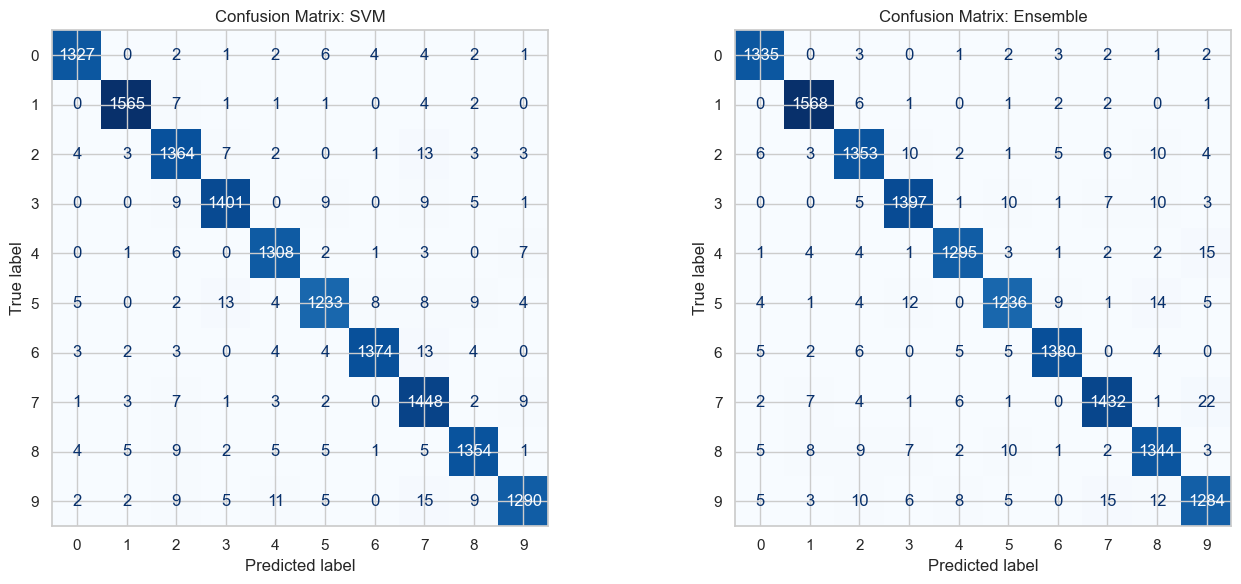

Generating Decision Boundary Plot (PCA 2D)...


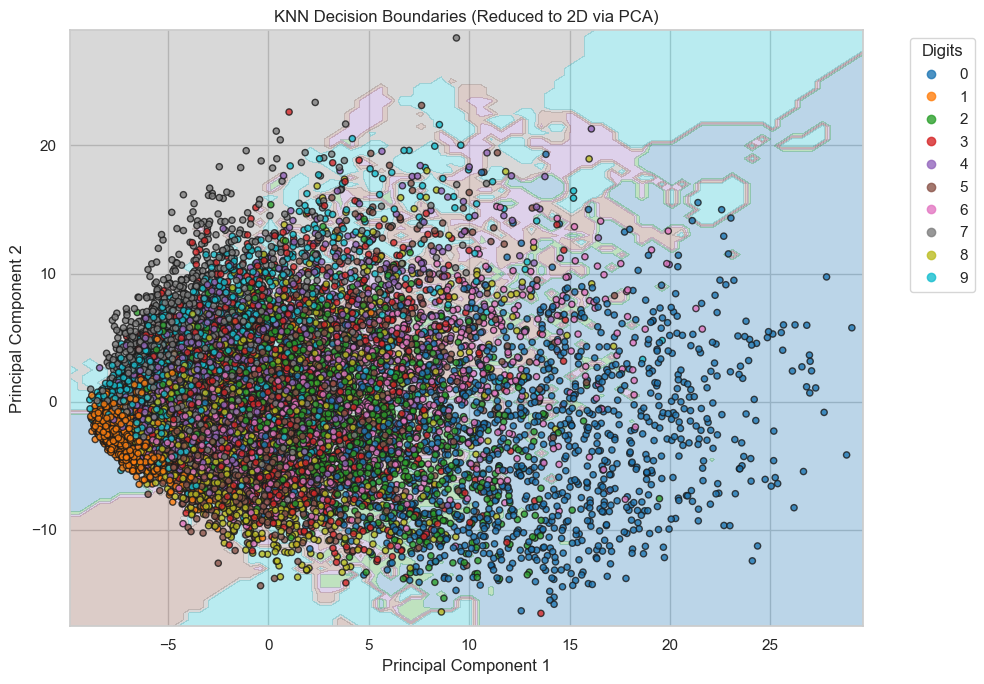

In [5]:
print("\n--- Phases 4 & 5: Algorithms & Evaluation ---")

param_svm = {'C': [1, 10], 'kernel': ['rbf']}
param_knn = {'n_neighbors': [3, 5], 'weights': ['distance']}
param_rf = {'n_estimators': [100], 'max_depth': [None, 10]}
models = {
    'SVM': (SVC(probability=True, random_state=42), param_svm),
    'KNN': (KNeighborsClassifier(), param_knn),
    'Random Forest': (RandomForestClassifier(random_state=42), param_rf)
}

best_estimators = {}

for name, (model, params) in models.items():
    print(f"Tuning {name}...")
    grid = GridSearchCV(model, params, cv=3, n_jobs=-1)
    grid.fit(X_train_pca, y_train)
    best_estimators[name] = grid.best_estimator_
    print(f"  Best Validation Score: {grid.best_score_:.4f}")

print("Training Voting Classifier (Ensemble)...")
ensemble_clf = VotingClassifier(
    estimators=[
        ('svm', best_estimators['SVM']),
        ('knn', best_estimators['KNN']),
        ('rf', best_estimators['Random Forest'])
    ],
    voting='soft'
)
ensemble_clf.fit(X_train_pca, y_train)
best_estimators['Ensemble'] = ensemble_clf

y_pred_ensemble = ensemble_clf.predict(X_test_pca)
print("\n--- Final Ensemble Test Results ---")
print(classification_report(y_test, y_pred_ensemble))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for i, name in enumerate(['SVM', 'Ensemble']):
    y_pred = best_estimators[name].predict(X_test_pca)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.unique(y))
    disp.plot(ax=axes[i], cmap='Blues', colorbar=False)
    axes[i].set_title(f'Confusion Matrix: {name}')
plt.tight_layout()
plt.show()


print("Generating Decision Boundary Plot (PCA 2D)...")
pca_2d = PCA(n_components=2)
X_train_2d = pca_2d.fit_transform(X_train_scaled) # Reduce to exactly 2 components
X_test_2d = pca_2d.transform(X_test_scaled)

knn_2d = best_estimators['KNN']
knn_2d.fit(X_train_2d, y_train)

x_min, x_max = X_test_2d[:, 0].min() - 1, X_test_2d[:, 0].max() + 1
y_min, y_max = X_test_2d[:, 1].min() - 1, X_test_2d[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.5), np.arange(y_min, y_max, 0.5))

Z = knn_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(10, 7))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='tab10')
scatter = plt.scatter(X_test_2d[:, 0], X_test_2d[:, 1], c=y_test, s=20, edgecolor='k', cmap='tab10', alpha=0.8)
plt.title('KNN Decision Boundaries (Reduced to 2D via PCA)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(*scatter.legend_elements(), title="Digits", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [6]:
import joblib

# Run this after Phase 5 in your notebook
joblib.dump(best_estimators['Ensemble'], 'mnist_ensemble.pkl')
joblib.dump(best_estimators['SVM'], 'mnist_svm.pkl')
joblib.dump(best_estimators['KNN'], 'mnist_knn.pkl')
joblib.dump(scaler, 'mnist_scaler.pkl')
joblib.dump(pca, 'mnist_pca.pkl')
print("Model and preprocessors saved for deployment!")

Model and preprocessors saved for deployment!


['mnist_knn.pkl']